<a href="https://colab.research.google.com/github/allnlk/ML/blob/main/%D0%9B%D0%A02_1_%D0%9A%D1%83%D0%B1%D1%80%D0%B0%D0%BA_3_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Кубрак, група 3-10

# Завдання 1

**Була присутня на парі**

Обробка та аналіз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [1]:
import numpy as np
import pandas as pd
import requests

In [6]:
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text

tables = pd.read_html(html)
df = tables[2]
df.head()

/tmp/ipykernel_2638/670621700.py:4: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


In [7]:
df.columns

Index(['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]',
       'United Nations (2024)[7]'],
      dtype='object')

2.	Визначити розмір датасета.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Country/Territory         222 non-null    object
 1   IMF (2026)[1]             222 non-null    object
 2   World Bank (2025)[6]      222 non-null    object
 3   United Nations (2024)[7]  222 non-null    object
dtypes: object(4)
memory usage: 7.1+ KB


 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [14]:
df.columns = (df.columns
              .str.replace(r'(?:\s*\[\d+\])+', '', regex=True)
              .str.replace('Country/Territory', 'Country', regex=False))
df.columns = ['Country', 'IMF', 'World_Bank', 'UN']

df.head()
df

,Country,IMF,World_Bank,UN
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


In [17]:
df = df.drop(df[df.iloc[:, 0] == "World"].index)
df

,Country,IMF,World_Bank,UN
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
5,United Kingdom,4264794,4002588,3685881
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [18]:
df.isnull().sum()

,0
Country,0
IMF,0
World_Bank,0
UN,0


In [23]:
df['IMF'] = pd.to_numeric(df['IMF'], errors='coerce')
df['World_Bank'] = pd.to_numeric(df['World_Bank'], errors='coerce')
df['UN'] = pd.to_numeric(df['UN'], errors='coerce')

In [25]:
df.dtypes

,0
Country,object
IMF,float64
World_Bank,float64
UN,float64


In [26]:
df

,Country,IMF,World_Bank,UN
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
5,United Kingdom,4264794.0,4002588.0,3685881.0
...,...,...,...,...
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,NaN,NaN,81.0


In [27]:
df.isnull().sum()

,0
Country,0
IMF,31
World_Bank,35
UN,9


In [30]:
df.iloc[:, 1:] = df.iloc[:, 1:].apply(lambda x: x.fillna(x.mean()), axis=1)

df.isnull().sum()

,0
Country,0
IMF,8
World_Bank,8
UN,8


In [31]:
part = df.iloc[:, 1:]

row_filled = part.apply(lambda r: r.fillna(r.mean()), axis=1)
col_means = part.mean()

df.iloc[:, 1:] = row_filled.fillna(col_means)

df.isnull().sum()

,0
Country,0
IMF,0
World_Bank,0
UN,0


5. Ще раз вивести датасет

In [32]:
df.tail(10)

,Country,IMF,World_Bank,UN
212,Saint Martin,594338.521127,556140.901408,524623.732394
213,Federated States of Micronesia,521.000000,502.000000,471.000000
214,Anguilla,456.000000,456.000000,456.000000
215,Cook Islands,414.000000,414.000000,414.000000
216,Kiribati,401.000000,349.000000,343.000000
217,Palau,377.000000,345.000000,310.000000
218,Marshall Islands,342.000000,308.000000,281.000000
219,Nauru,196.000000,176.000000,187.000000
220,Montserrat,81.000000,81.000000,81.000000
221,Tuvalu,65.000000,57.000000,56.000000


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [33]:
df.duplicated().sum()

np.int64(0)

7.	Вивести описову статистику датасету describe()

In [34]:
df.describe()

,IMF,World_Bank,UN
count,2.210000e+02,2.210000e+02,2.210000e+02
mean,5.943385e+05,5.561409e+05,5.246237e+05
std,2.673673e+06,2.527950e+06,2.410273e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,9.442000e+03,9.233000e+03,8.840000e+03
50%,4.884900e+04,4.809900e+04,4.276500e+04
75%,3.773650e+05,3.348550e+05,2.986970e+05
max,3.238392e+07,3.076970e+07,2.929800e+07


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [36]:
df['IMF_WB_Diff'] = abs(df['IMF'] - df['World_Bank'])

max_diff = df['IMF_WB_Diff'].max()

country = df[df['IMF_WB_Diff'] == max_diff]['Country'].values[0]

print(f'{country} has the largest difference between IMF and WB: {max_diff}')
df.head(10)


United States has the largest difference between IMF and WB: 1614220.0


,Country,IMF,World_Bank,UN,IMF_WB_Diff
1,United States,32383920.0,30769700.0,29298000.0,1614220.0
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0
3,Germany,5452858.0,5050923.0,4659929.0,401935.0
4,Japan,4379253.0,4435163.0,4026211.0,55910.0
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0
6,India,4153191.0,3956067.0,3952244.0,197124.0
7,France,3596094.0,3366316.0,3160443.0,229778.0
8,Italy,2738164.0,2551557.0,2380825.0,186607.0
9,Russia,2656452.0,2561310.0,2173386.0,95142.0
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0


Найбільша різниця спостерігається у США — показники МВФ та Світового банку відрізняються на 1 614 220.

9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [39]:
cor_IMF_WB = df['IMF'].corr(df['World_Bank'])
cor_IMF_UN = df['IMF'].corr(df['UN'])
cor_WB_UN = df['World_Bank'].corr(df['UN'])

print(f'Correlation between IMF and WB: {cor_IMF_WB}')
print(f'Correlation between IMF and UN: {cor_IMF_UN}')
print(f'Correlation between WB and UN: {cor_WB_UN}')


Correlation between IMF and WB: 0.9998772853399375
Correlation between IMF and UN: 0.9998162531253877
Correlation between WB and UN: 0.9998603541665632


In [41]:
max_cor = max(cor_IMF_WB, cor_IMF_UN, cor_WB_UN)

if max_cor == cor_IMF_WB:
    print('IMF and World Bank have the highest correlation')
elif max_cor == cor_IMF_UN:
    print('IMF and UN have the highest correlation')
else:
    print('World Bank and UN have the highest correlation')

IMF and World Bank have the highest correlation


Найвищу кореляцію мають показники МВФ (IMF) та Світового банку (World Bank) — вона становить приблизно 0.9999 (майже 1).

Обчислити середнє значення за стовпцями

In [42]:
mean_IMF = df['IMF'].mean()
mean_IMF

np.float64(594338.5211267605)

In [43]:
mean_World_Bank = df['World_Bank'].mean()
mean_World_Bank

np.float64(556140.9014084507)

In [44]:
mean_UN = df['UN'].mean()
mean_UN

np.float64(524623.7323943662)

11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [46]:
df['std'] = df[['IMF', 'World_Bank', 'UN']].std(axis=1)

max_std = df['std'].max()
country = df[df['std'] == max_std]['Country'].values[0]

print(f'{country} has the highest standard deviation: {max_std}')
df.head(10)

United States has the highest standard deviation: 1543508.4140144275


,Country,IMF,World_Bank,UN,IMF_WB_Diff,std
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.543508e+06
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,1.068002e+06
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,3.964771e+05
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.217380e+05
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,2.898838e+05
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.149291e+05
7,France,3596094.0,3366316.0,3160443.0,229778.0,2.179348e+05
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.787283e+05
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,2.558938e+05
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,2.374046e+05


Найбільшу варіативність (стандартне відхилення) мають США (United States) — значення становить приблизно 1 543 508.

12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [47]:
max_IMF = df['IMF'].max(); min_IMF = df['IMF'].min()
max_World_Bank = df['World_Bank'].max(); min_World_Bank = df['World_Bank'].min()
max_UN = df['UN'].max(); min_UN = df['UN'].min()

print(f'Max IMF: {max_IMF}, Min IMF: {min_IMF}')
print(f'Max World_Bank: {max_World_Bank}, Min World Bank: {min_World_Bank}')
print(f'Max UN: {max_UN}, Min UN: {min_UN}')

Max IMF: 32383920.0, Min IMF: 65.0
Max World_Bank: 30769700.0, Min World Bank: 57.0
Max UN: 29298000.0, Min UN: 56.0




* IMF (2026): Максимум — США (32 383 920), Мінімум — Тувалу (65).
* World Bank (2025): Максимум — США (30 769 700), Мінімум — Тувалу (57).
* United Nations (2024): Максимум — США (29 298 000), Мінімум — Тувалу (56).

13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

<function matplotlib.pyplot.show(close=None, block=None)>

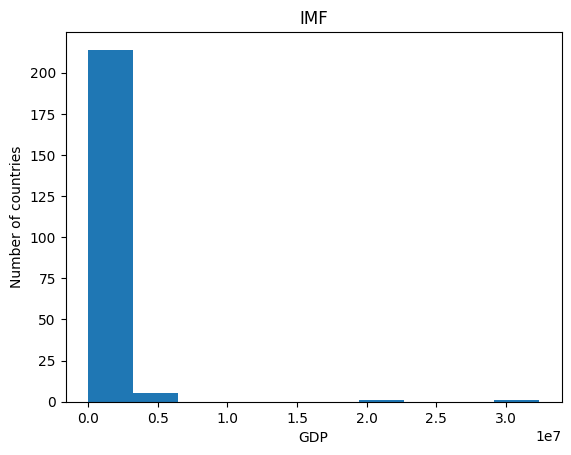

In [52]:
import matplotlib.pyplot as plt

plt.hist(df['IMF'], bins = 10)
plt.title('IMF')
plt.xlabel('GDP')
plt.ylabel('Number of countries')
plt.show

Розподіл є сильно асиметричним тобто зміщеним праворуч: більшість країн зосереджені в першому стовпчикi з найнижчими значеннями ВВП.

Чітко виділяються дві країни з величезним розривом від усіх інших — США та Китай.

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [49]:
df['IMF_Share'] = df['IMF'] / df['IMF'].sum()
df['World_Bank'] = df['World_Bank'] / df['World_Bank'].sum()
df['UN'] = df['UN'] / df['UN'].sum()

df.head(10)

,Country,IMF,World_Bank,UN,IMF_WB_Diff,std,IMF_Share
1,United States,32383920.0,0.250349,0.252696,1614220.0,1.543508e+06,0.246549
2,China[n 1],20851593.0,0.158640,0.161666,1353554.0,1.068002e+06,0.158750
3,Germany,5452858.0,0.041095,0.040192,401935.0,3.964771e+05,0.041514
4,Japan,4379253.0,0.036085,0.034726,55910.0,2.217380e+05,0.033341
5,United Kingdom,4264794.0,0.032566,0.031791,262206.0,2.898838e+05,0.032469
6,India,4153191.0,0.032187,0.034088,197124.0,1.149291e+05,0.031620
7,France,3596094.0,0.027389,0.027259,229778.0,2.179348e+05,0.027378
8,Italy,2738164.0,0.020760,0.020535,186607.0,1.787283e+05,0.020847
9,Russia,2656452.0,0.020839,0.018745,95142.0,2.558938e+05,0.020224
10,Brazil,2635912.0,0.018550,0.018853,355992.0,2.374046e+05,0.020068


Частки зростають: США (з 25.27% у UN до 25.03% у WB і 24.65% у IMF) та Японія демонструють тенденцію до зниження частки, тоді як росія та Туреччина показують зростання від UN до WB/IMF.

Частки більшості розвинених країн залишаються досить стабільними із незначними коливаннями в межах 0.1% – 0.6%.

15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

In [51]:
df['IMF_UN_Diff'] = abs(df['IMF_Share'] - df['UN'])

df_top10 = df.nlargest(10, 'IMF_UN_Diff')
df_top10

,Country,IMF,World_Bank,UN,IMF_WB_Diff,std,IMF_Share,IMF_UN_Diff
1,United States,32383920.0,0.250349,0.252696,1614220.0,1.543508e+06,0.246549,0.006147
2,China[n 1],20851593.0,0.158640,0.161666,1353554.0,1.068002e+06,0.158750,0.002916
6,India,4153191.0,0.032187,0.034088,197124.0,1.149291e+05,0.031620,0.002469
53,Iran,300293.0,0.002951,0.003865,62389.0,7.419771e+04,0.002286,0.001579
9,Russia,2656452.0,0.020839,0.018745,95142.0,2.558938e+05,0.020224,0.001479
15,South Korea,1931008.0,0.015234,0.016175,58633.0,3.301639e+04,0.014701,0.001474
4,Japan,4379253.0,0.036085,0.034726,55910.0,2.217380e+05,0.033341,0.001385
3,Germany,5452858.0,0.041095,0.040192,401935.0,3.964771e+05,0.041514,0.001322
10,Brazil,2635912.0,0.018550,0.018853,355992.0,2.374046e+05,0.020068,0.001215
16,Turkey,1640223.0,0.012996,0.011413,42930.0,1.719537e+05,0.012488,0.001074


Стабільне зростання/висока розбіжність: США та Китай показують найбільший  розрив у показниках між оцінками МВФ, Світового банку та ООН, а також найбільші коливання частки у світовому ВВП.

Для більшості інших країн (Німеччина, Японія, Бразилія) показники є дуже стабільними — відхилення між трьома джерелами є мінімальним і не перевищує 0.1%–0.6%.